# NLP and Sequence Modeling Mini Project

## Part 3: Text Classification and Sequence Modeling

### Objective

The objective of this project is to understand how Natural Language Processing (NLP) techniques are used for text classification tasks.

This notebook demonstrates:

- Dataset understanding and analysis
- Text preprocessing techniques
- Text vectorization using TF-IDF
- Baseline machine learning model
- Sequence modeling using LSTM
- Understanding attention mechanisms and transformers

---

In [54]:
print("Project Started Successfully")

Project Started Successfully


In [88]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Downloading required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [56]:
import nltk

print("NLTK Working Successfully")

NLTK Working Successfully


# Loading the Dataset

The dataset contains customer support related text records and their corresponding categories or labels.

The dataset is loaded using the pandas library.

In [57]:
# Loading dataset

df = pd.read_csv("customer_support_text_classification.csv")

# Display first five rows
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


# Dataset Understanding

In this section, the dataset structure and characteristics are analyzed.

The following information is explored:

- Number of records
- Dataset columns
- Sample text records
- Target classes
- Average text length
- Class distribution

In [58]:
# Shape of dataset

print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 6)


In [59]:
# Display dataset columns

print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [60]:
# Checking sample records

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [61]:
# Replace column names if needed

text_column = "customer_message"
target_column = "sentiment_label"

In [62]:
# Display sample text

print(df[text_column].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


In [63]:
# Class distribution

print(df[target_column].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [64]:
# Calculating text length

df["text_length"] = df[text_column].apply(len)

print("Average Text Length:", df["text_length"].mean())

Average Text Length: 72.75666666666666


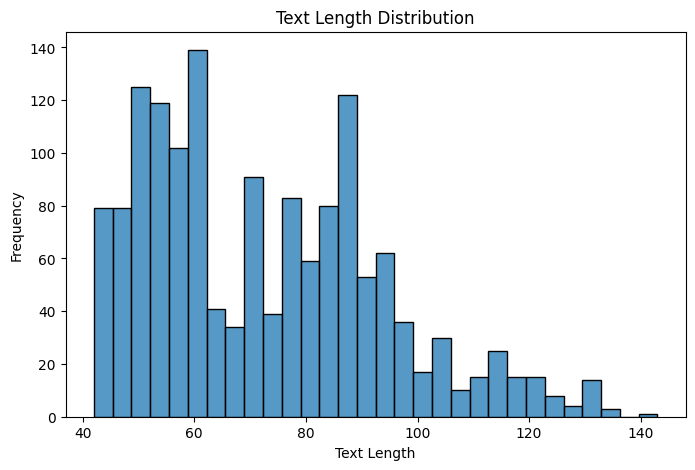

In [65]:
# Plotting text length distribution

plt.figure(figsize=(8,5))

sns.histplot(df["text_length"], bins=30)

plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")

plt.show()

# Plotting class distribution
# Text Preprocessing

Text preprocessing is an important step in NLP.

The following preprocessing operations are performed:

- Lowercasing
- Removing special characters
- Tokenization
- Stopword removal

These steps help improve text quality and model performance.

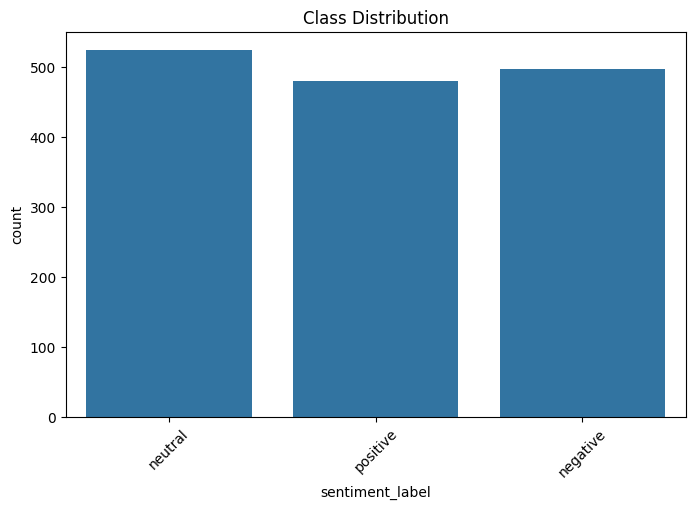

In [66]:
plt.figure(figsize=(8,5))

sns.countplot(x=df[target_column])

plt.title("Class Distribution")

plt.xticks(rotation=45)

plt.show()

In [67]:
# Loading stopwords

stop_words = set(stopwords.words('english'))

In [68]:
# Text cleaning function

def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

In [69]:
# Applying preprocessing

df["clean_text"] = df[text_column].apply(clean_text)

df[["clean_text"]].head()

,clean_text
0,need information payment process ticket number...
1,need information payment process
2,refund process fast convenient appreciate quic...
3,refund still pending experience frustrating ti...
4,please tell update account details


# Label Encoding

Machine learning models require numerical target values.

Label encoding converts text labels into numeric form.

In [70]:
# Encoding labels

encoder = LabelEncoder()

df[target_column] = encoder.fit_transform(df[target_column])

# Splitting the Dataset

The dataset is divided into training and testing sets.

- Training data is used for learning
- Testing data is used for evaluation

In [71]:
# Features and target

X = df["clean_text"]
y = df[target_column]

In [72]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TF-IDF Vectorization

Machine learning models cannot directly process raw text.

TF-IDF converts text into numerical vectors based on word importance within the dataset.

In [73]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

# Baseline Model

A Logistic Regression model is used as the baseline machine learning model for text classification.

In [74]:
# Training Logistic Regression model

baseline_model = LogisticRegression()

baseline_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [75]:
# Predictions

y_pred = baseline_model.predict(X_test_tfidf)

# Model Evaluation

The model performance is evaluated using:

- Accuracy Score
- Classification Report
- Confusion Matrix

In [76]:
# Accuracy score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


In [77]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



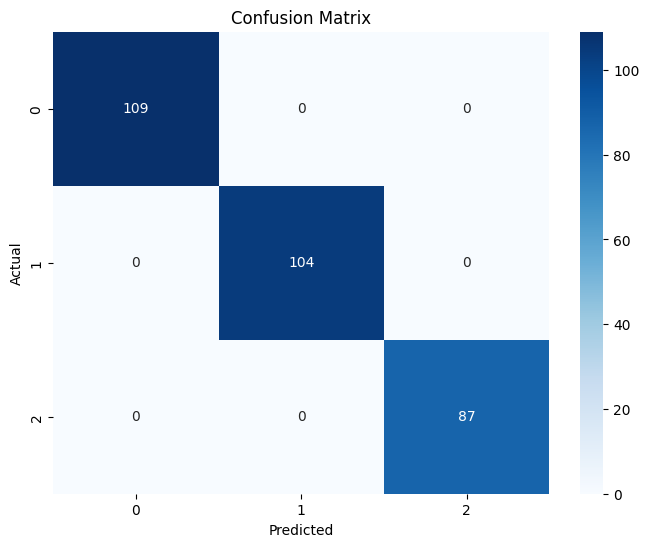

In [78]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Sequence Modeling using LSTM

Unlike traditional vectorization methods, sequence models understand the order of words.

LSTM networks are designed to capture long-term dependencies in text sequences.

In [79]:
# Tokenizer initialization

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train)

In [80]:
# Converting text into sequences

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [81]:
# Padding sequences

max_length = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

# LSTM Architecture

The sequence model contains:

- Embedding Layer
- LSTM Layer
- Dense Output Layer

The embedding layer converts words into dense vector representations.

The LSTM layer processes sequential information from the text.

In [82]:
# Building LSTM model

lstm_model = Sequential([

    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=max_length
    ),

    LSTM(64),

    Dense(64, activation='relu'),

    Dense(len(df[target_column].unique()), activation='softmax')
])

c:\Users\asus\Downloads\part-3-nlp-sequence-modeling\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [83]:
# Compiling model

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [84]:
# Model summary

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [85]:
# Training LSTM model

history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.3375 - loss: 1.0993 - val_accuracy: 0.3292 - val_loss: 1.0994
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3552 - loss: 1.0982 - val_accuracy: 0.3292 - val_loss: 1.0999
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3552 - loss: 1.0986 - val_accuracy: 0.3292 - val_loss: 1.0992
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3552 - loss: 1.0991 - val_accuracy: 0.3292 - val_loss: 1.1000
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3552 - loss: 1.0985 - val_accuracy: 0.3292 - val_loss: 1.1001


# LSTM Model Evaluation

In [86]:
# Evaluating LSTM model

loss, accuracy = lstm_model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3467 - loss: 1.0977
Test Accuracy: 0.3466666638851166


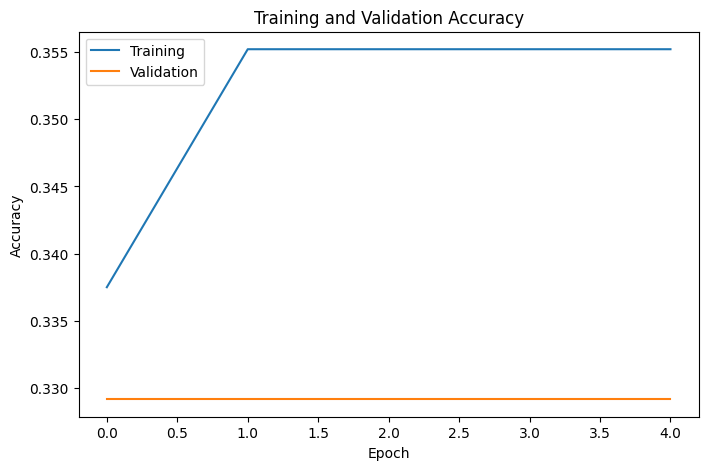

In [87]:
# Plotting training accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Training', 'Validation'])

plt.show()

# Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

Traditional RNNs process information sequentially, which makes it difficult to retain information from earlier parts of long sequences.

This issue is commonly known as the vanishing gradient problem.

---

## How LSTMs Help

LSTMs introduce memory cells and gating mechanisms that help preserve important information over longer sequences.

This improves sequence learning performance.

---

## What Attention Solves

Attention mechanisms allow models to focus on important parts of the input sequence.

This improves tasks such as:

- Machine translation
- Text summarization
- Question answering

---

## Importance of Transformers

Transformers use self-attention and parallel processing instead of sequential processing.

Advantages include:

- Faster training
- Better contextual understanding
- Improved handling of long sequences

Transformers form the foundation of modern Generative AI systems such as GPT and BERT.

# Conclusion

This project demonstrated the complete NLP pipeline for text classification.

The project included:

- Text preprocessing
- TF-IDF vectorization
- Logistic Regression baseline model
- LSTM sequence modeling
- Attention and transformer concepts

The implementation highlights the difference between traditional NLP methods and deep learning based sequence models.

In [89]:
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results_df.to_csv(
    "results/model_evaluation.csv",
    index=False
)

In [90]:
with open("results/sample_predictions.txt", "w") as f:

    for i in range(10):

        f.write(f"Text: {X_test.iloc[i]}\n")
        f.write(f"Actual: {y_test.iloc[i]}\n")
        f.write(f"Predicted: {y_pred[i]}\n")
        f.write("\n")

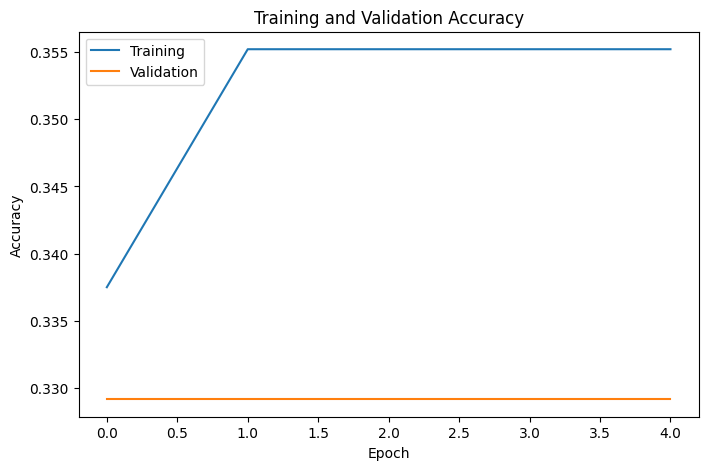

In [91]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Training', 'Validation'])

# Save graph
plt.savefig("results/accuracy_plot.png")

plt.show()